In [1]:
import pandas as pd
import numpy as np

train = pd.read_csv('/kaggle/input/playground-series-s5e8/train.csv')
test = pd.read_csv('/kaggle/input/playground-series-s5e8/test.csv')
sample_submission = pd.read_csv("/kaggle/input/playground-series-s5e8/sample_submission.csv")
train.head()

,id,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,0,42,technician,married,secondary,no,7,no,no,cellular,25,aug,117,3,-1,0,unknown,0
1,1,38,blue-collar,married,secondary,no,514,no,no,unknown,18,jun,185,1,-1,0,unknown,0
2,2,36,blue-collar,married,secondary,no,602,yes,no,unknown,14,may,111,2,-1,0,unknown,0
3,3,27,student,single,secondary,no,34,yes,no,unknown,28,may,10,2,-1,0,unknown,0
4,4,26,technician,married,secondary,no,889,yes,no,cellular,3,feb,902,1,-1,0,unknown,1


In [2]:
print(train.shape)
print(train.info())
print(train.describe())

(750000, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750000 entries, 0 to 749999
Data columns (total 18 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   id         750000 non-null  int64 
 1   age        750000 non-null  int64 
 2   job        750000 non-null  object
 3   marital    750000 non-null  object
 4   education  750000 non-null  object
 5   default    750000 non-null  object
 6   balance    750000 non-null  int64 
 7   housing    750000 non-null  object
 8   loan       750000 non-null  object
 9   contact    750000 non-null  object
 10  day        750000 non-null  int64 
 11  month      750000 non-null  object
 12  duration   750000 non-null  int64 
 13  campaign   750000 non-null  int64 
 14  pdays      750000 non-null  int64 
 15  previous   750000 non-null  int64 
 16  poutcome   750000 non-null  object
 17  y          750000 non-null  int64 
dtypes: int64(9), object(9)
memory usage: 103.0+ MB
None
                  i

In [3]:
train.isnull().sum().sum()

np.int64(0)

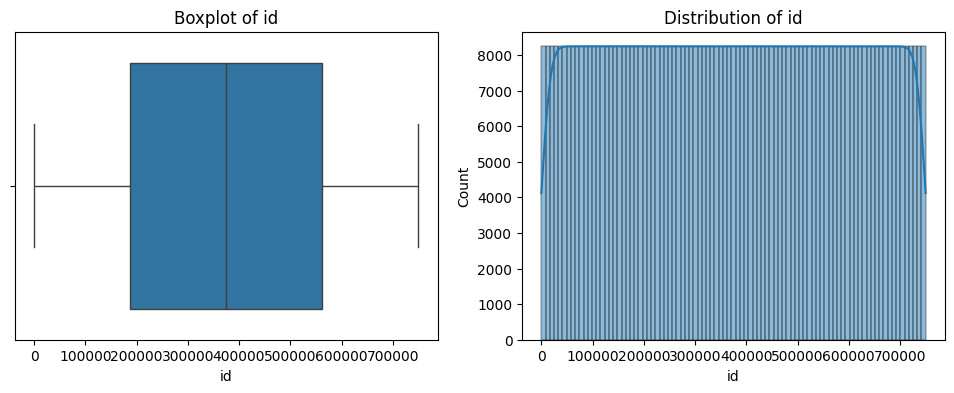

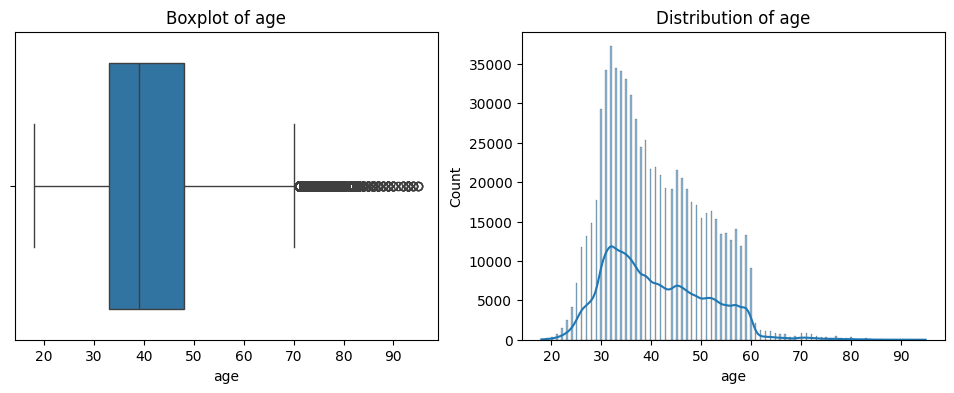

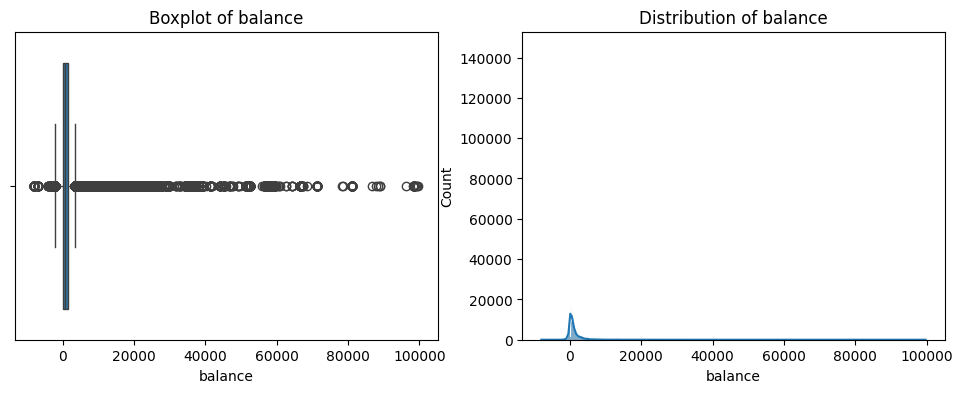

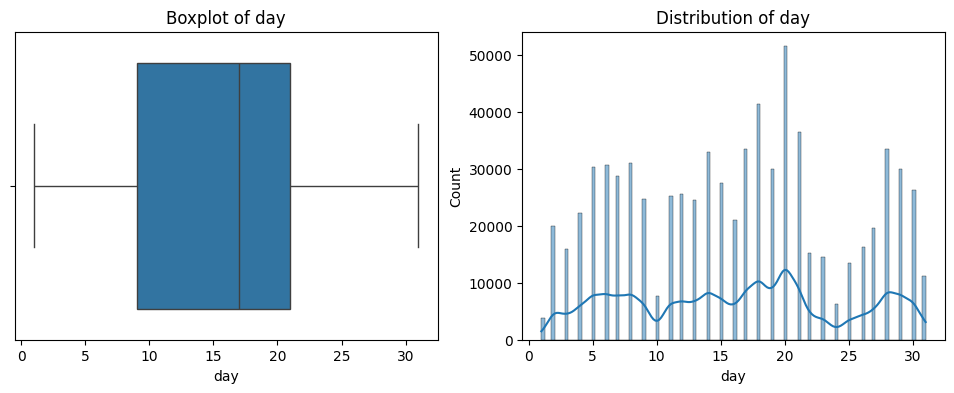

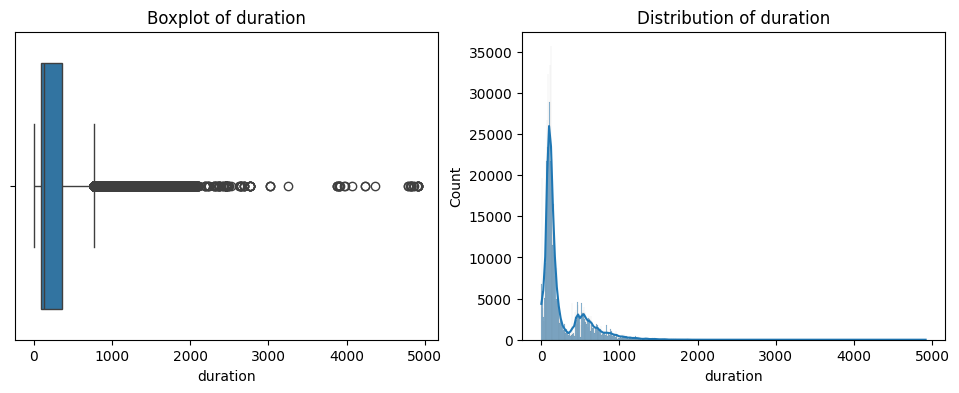

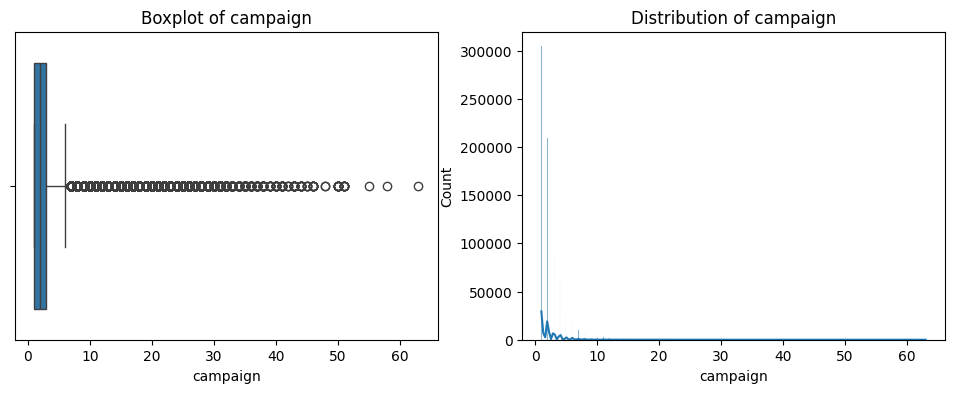

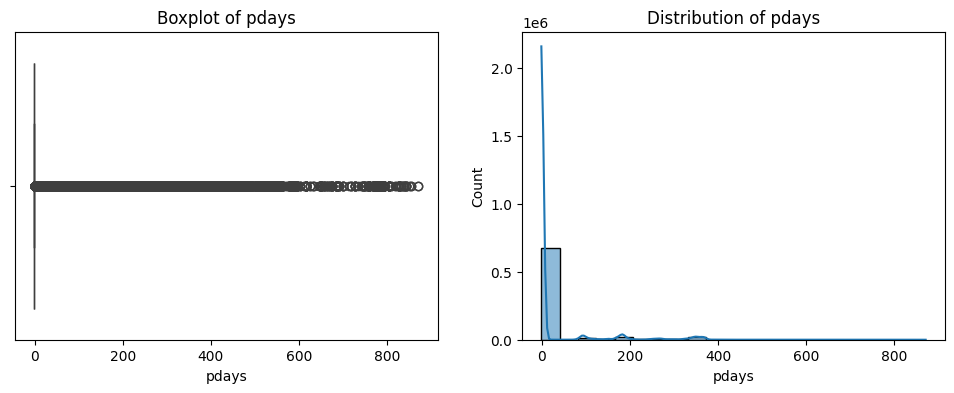

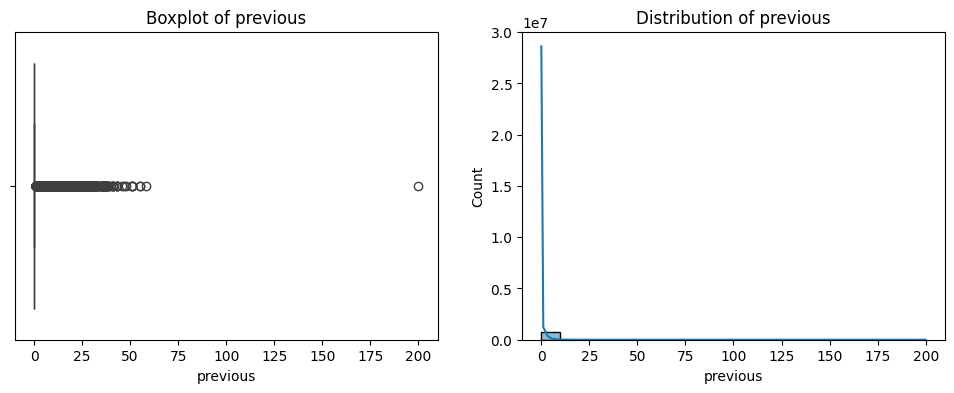

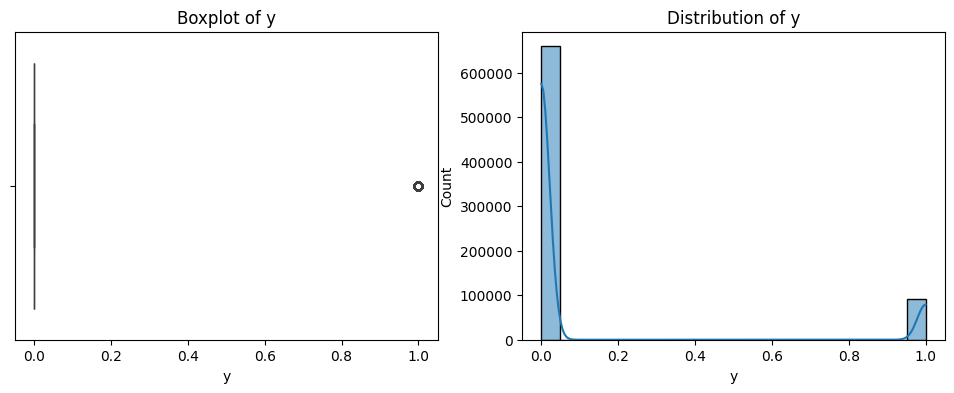

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = train.select_dtypes(include='number').columns

for col in num_cols:
    fig, axes = plt.subplots(1,2, figsize=(12,4))
    
    sns.boxplot(x=train[col], ax=axes[0])
    axes[0].set_title(f"Boxplot of {col}")
    
    sns.histplot(train[col], kde=True, ax=axes[1])
    axes[1].set_title(f"Distribution of {col}")
    
    plt.show()

In [5]:
X = train.drop(columns=["id", "y"])
y = train["y"]

In [6]:
from sklearn.preprocessing import LabelEncoder

test_processed = test.drop(columns=["id"])

cat_columns = X.select_dtypes(include=['object']).columns

le = LabelEncoder()

for col in cat_columns:
    X[col] = le.fit_transform(X[col].astype(str))
    test_processed[col] = le.fit_transform(test_processed[col].astype(str))

In [7]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

model = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

val_preds = model.predict_proba(X_val)[:,1]

roc_auc_score(y_val, val_preds)

np.float64(0.9635615941584643)

In [9]:
test_preds = model.predict_proba(test_processed)[:,1]
test_preds[:10]

array([0.   , 0.198, 0.   , 0.   , 0.052, 0.002, 0.602, 0.162, 0.01 ,
       0.344])

In [10]:
submission = sample_submission.copy()
submission["y"] = test_preds

submission.to_csv("submission.csv", index=False)